In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from netCDF4 import Dataset
import pp_model.PPmodel as pr

plt.rcParams["savefig.format"] = 'pdf'

plt.rcParams['figure.figsize'] = [10,10]
plt.rcParams['figure.dpi'] = 50
plt.rcParams['savefig.dpi'] = 256

plt.rcParams['font.size'] = 25
plt.rcParams['legend.fontsize'] = 'large'
plt.rcParams['figure.titlesize'] = 'large'

In [ ]:
#set file number
fold_num = 4
file_num = 24
file_num_str = str(file_num).zfill(2)

path = ('LES/%d/Precip/EMUSCU_snd_0'+ file_num_str +
             '/EMULATOR_SCU_240x240x250_dx200_dz10_dt1s_12h.nc') %fold_num
nc = Dataset(path)

In [17]:
t  = nc.variables['time'][:]
CLD = nc.variables['CLD'][:]
N = nc.variables['NC'][:]
CLDLOW = nc.variables['CLDLOW'][:]
spin_up = pr.find_spinup_end(CLDLOW)
print(spin_up)

140


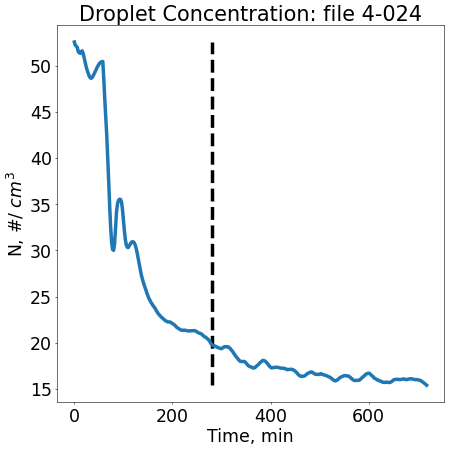

In [20]:
N_ave = np.mean(N, axis=1) / np.mean(CLD, axis=1)
N_ave = N_ave[:]#int(4.5 * 60):]
plt.plot([spin_up*2]*2,
         [np.amin(N_ave), np.amax(N_ave)],
         '--',
         color = 'k',
         linewidth = 5)
plt.plot(np.arange(0, 720, 2), 
         N_ave,
         color='C0',
         linewidth = 5)
plt.xlabel('Time, min')
plt.ylabel('N, #/ $cm^3$')
plt.title(('Droplet Concentration: file %d-0' + file_num_str)%fold_num)
#plt.text(100/2,45,'Dense phase')
#plt.text(850/2 ,45,'Sparse phase')
plt.show()

In [6]:
# print(' Dense average N: ',np.mean(N_ave[:int(8*30)-int(4.5*30)]))
print('Sparse average N: ',np.mean(N_ave[int(8*30)-int(4.5*30):]))

Sparse average N:  16.005563534007354


In [7]:
print('Average drop concentration at the boundary')
print('between the dense and sparse phases: %.1f #/cm^3'%(round(N_ave[105], 1)))


Average drop concentration at the boundary
between the dense and sparse phases: 22.0 #/cm^3
